# Partie A: Clustering

- **Dataset**: Mall Customer Segmentation Data
- **Objectifs**: Segmenter les clients du centre commercial en groupes homogènes.

In [1]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

# 1. Chargement:
Chargement du fichier `Mall_Customer.csv`

In [2]:
# Chargement du DataSet
dataset=pd.read_csv('../dataset/Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 2. Nettoyage et prétraitement:

In [3]:
# Nettoyage et prétraitement
##  Gender : Supprimer les NaN
dataset['Gender'].dropna(inplace=True)
##  TODO Age: Superieure à 18
dataset['Age']=dataset['Age'].fillna(18)
## Normalisation de Annual Income: Positifs et Spending Score: Entre 1-100
scaler = MinMaxScaler()
dataset[['Annual Income (k$)', 'Spending Score (1-100)']] = scaler.fit_transform(dataset[['Annual Income (k$)', 'Spending Score (1-100)']])

## Remplacer:
##   Male   par 0
##   Female par 1
dataset['Gender']=dataset['Gender'].replace({"Male":0,"Female":1})
dataset.head()


C:\Users\Fox\AppData\Local\Temp\ipykernel_15596\4182022866.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['Gender']=dataset['Gender'].replace({"Male":0,"Female":1})


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,0.000000,0.387755
1,2,0,21,0.000000,0.816327
2,3,1,20,0.008197,0.051020
3,4,1,23,0.008197,0.775510
4,5,1,31,0.016393,0.397959


# 3. EDA univariée et multivariée :

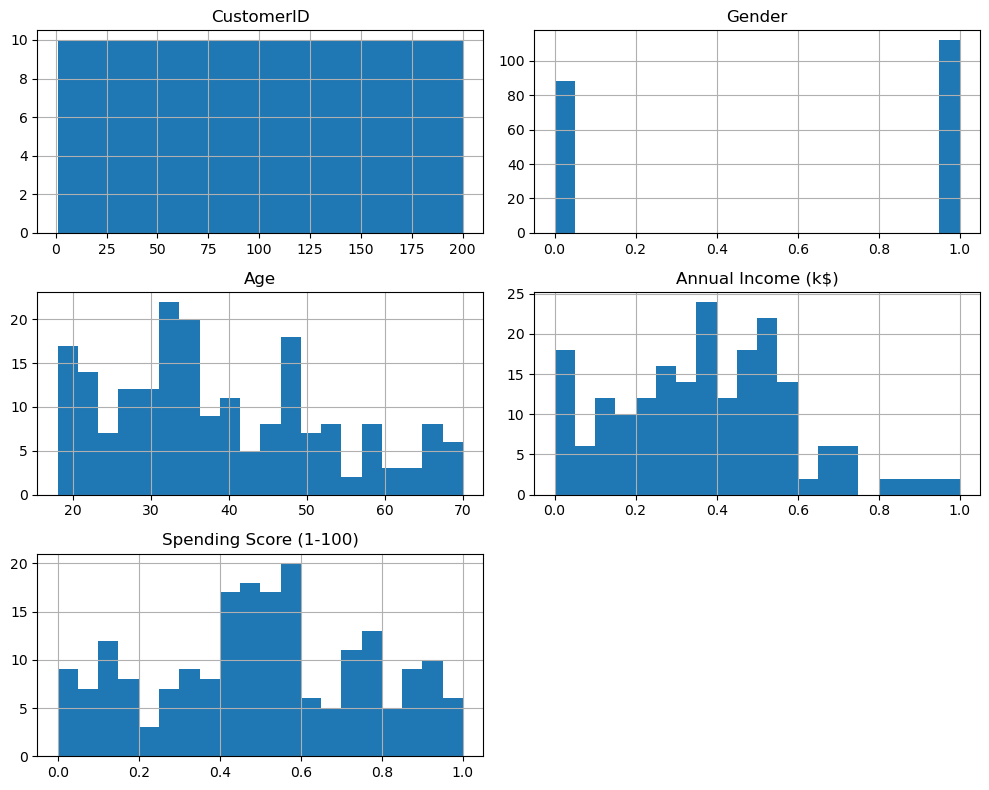

In [4]:
# Histogramme de Chaque Variables
dataset.hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

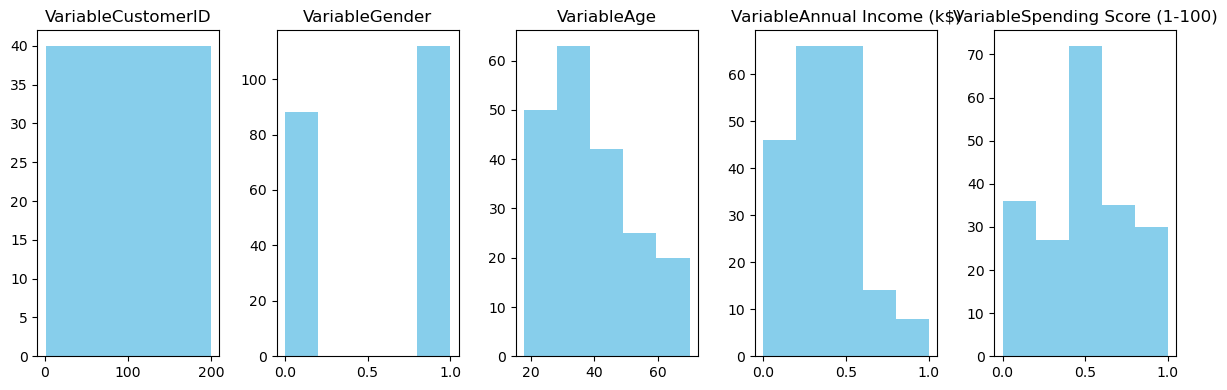

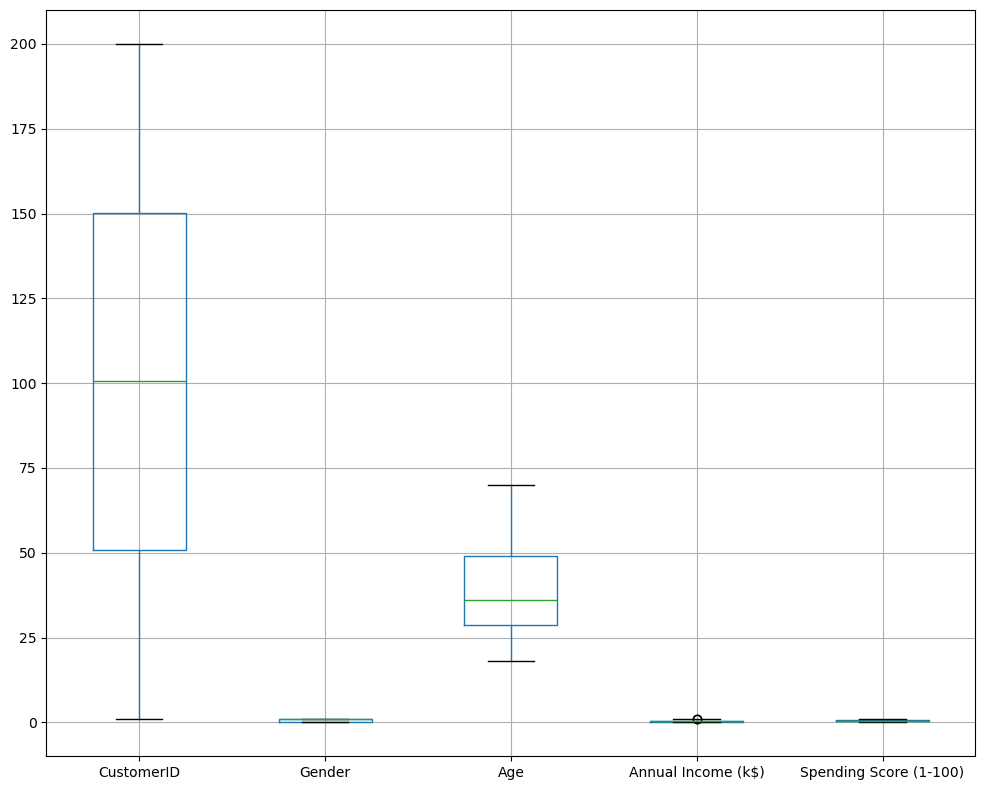

In [5]:
# BoxLayout de Chaque Variables
# Modifier en Subplot pour chaque Variable
fig, axes = plt.subplots(1, 5, figsize=(12,4))

for i, col in enumerate(dataset.columns):
    axes[i].hist(dataset[col], bins=5, color='skyblue')
    axes[i].set_title(f'Variable{col}')

plt.tight_layout()
plt.show()

dataset.boxplot(figsize=(10, 8))
plt.tight_layout()
plt.show()

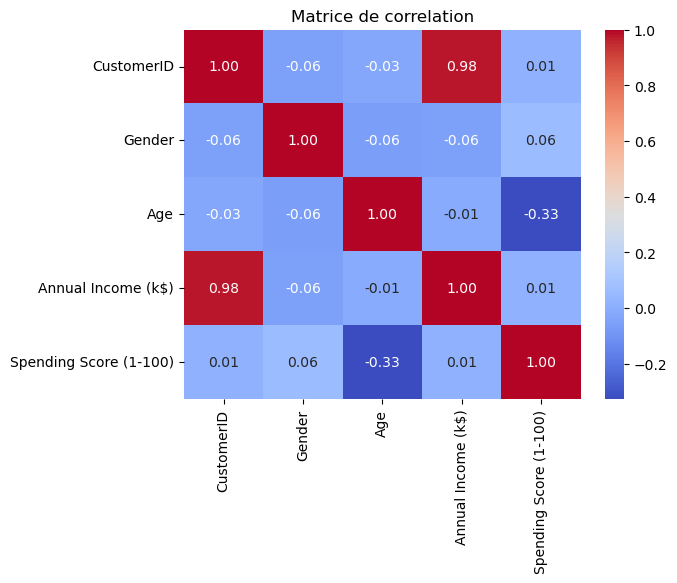

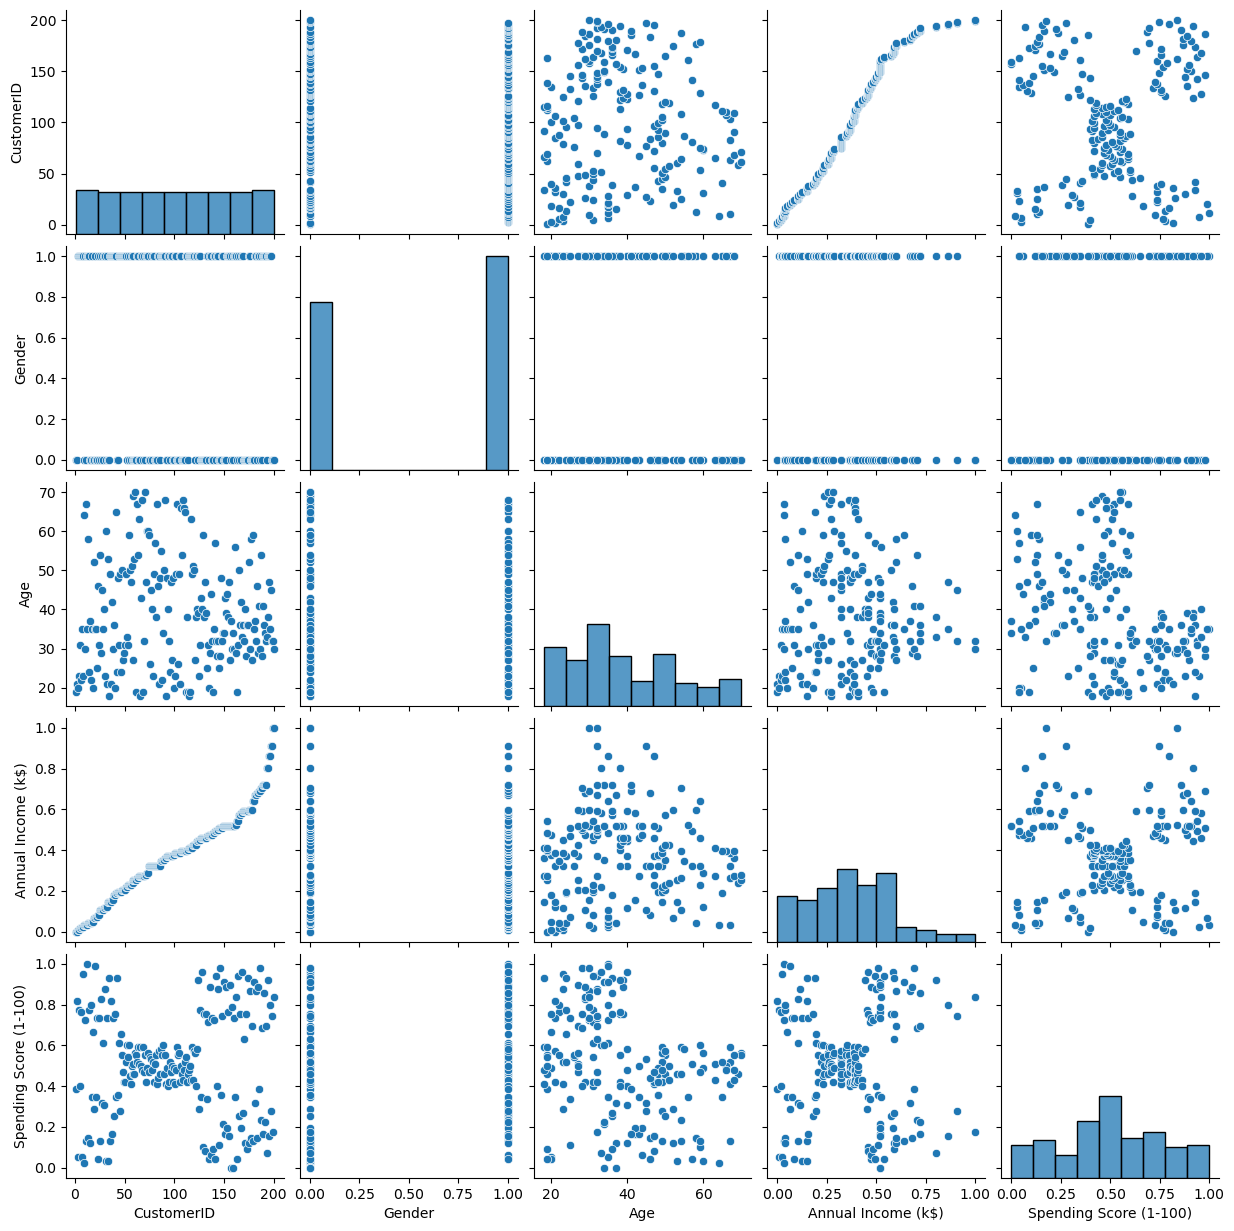

In [6]:
# Matrice de Correlation
corr_matrix=dataset.corr()
#print("La matrice de Correlation :",corr_matrix)

# Affichage en Heatmap 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de correlation')
plt.show()

# Scatter Plot
sns.pairplot(dataset, kind='scatter')
plt.show()

# 4. Feature engineering / sélection: 

In [7]:
# Supprimer les features non informatives et Redondantes
## Supprimer CustomerID car non-informatives
dataset_select=dataset.drop('CustomerID', axis=1)
dataset_select.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,0.000000,0.387755
1,0,21,0.000000,0.816327
2,1,20,0.008197,0.051020
3,1,23,0.008197,0.775510
4,1,31,0.016393,0.397959


In [15]:
# Categoriser des Variables
# TODO:
#creation de nouvelle variable 



# 5. Reduction de Dimension:


In [9]:
# Application de PCA pour la Visualisation en 2D
pca = PCA(n_components=2) # 2 Composants

# Separer les features des Targets (X et Y)
## Features: Gender, Age , Annual Income
## Target : Spending Score

X=dataset_select.drop("Spending Score (1-100)",axis=1) # Exclure Spending Score
Y=dataset_select["Spending Score (1-100)"]

# Application du PCA pour Reduire en 2 dimension
X_pca=pca.fit_transform(X)

#Conversion en Dataframe
df_pca=pd.DataFrame(data=X_pca,columns=['component1','component2'])

df_pca.head()

,component1,component2
0,-19.848666,-0.591300
1,-17.848670,-0.586972
2,-18.850841,0.410146
3,-15.850848,0.416638
4,-7.850868,0.433702


# 6. Clustering

In [10]:
# Clustering K means

## Variables pour Stocker les Resultats
inertias = []
silhouettes = []
K_range = range(2, 7)

## 
for i, k in enumerate(K_range, 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# 
print("Elbow:",inertias)
print("Silhouette",silhouettes)

Elbow: [10615.88659429576, 6089.450517092644, 2590.125651122833, 1919.1266134958476, 1222.7523390408292]
Silhouette [0.6294592443866088, 0.5487779088430412, 0.5890775628715786, 0.5675984457675074, 0.5695102989789573]


c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with M

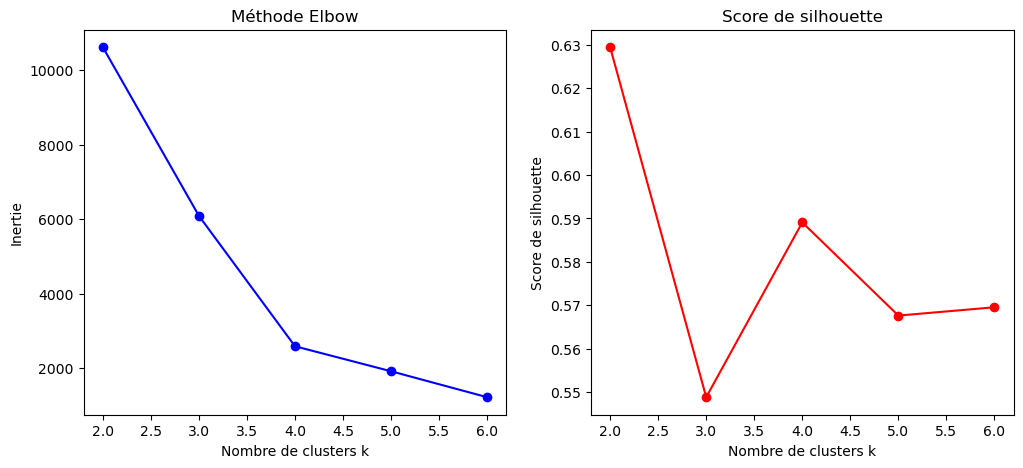

In [11]:
# Affichage de Elbow et Sihouettes

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Méthode Elbow')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette')

plt.show()

# 7. Interpretation des Clusters

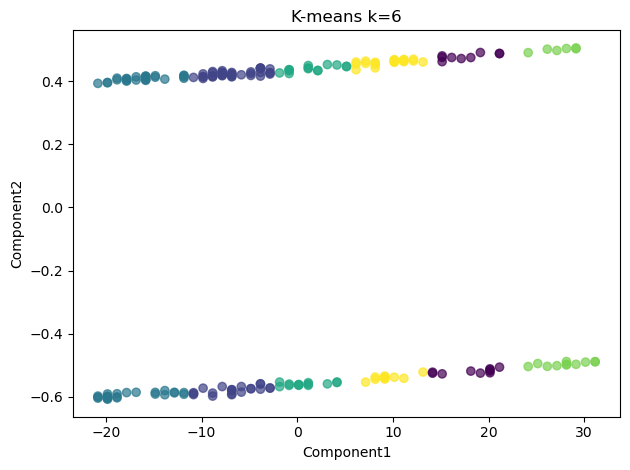

In [12]:
# Analyses Des Centroides

# TODO : analyse des centroides

# Visualisation 2D Coloré par Cluster
#plt.figure(figsize=(15, 5))

#for i, k in enumerate(K_range, 1):
    # Visualisation clusters en 2D
#plt.subplot(1, len(K_range), i)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f'K-means k={k}')
plt.xlabel('Component1')
plt.ylabel('Component2')

plt.tight_layout()
plt.show()